In [ ]:
# # src/correction_fusion.py
# import numpy as np
# import pandas as pd
# from pathlib import Path
# import matplotlib.pyplot as plt
# import mediapipe as mp
# import cv2

# # Paths (adjust if needed)
# PROC_DIR = Path("../data/processed")
# PROCESSED_TRAIN = PROC_DIR / "processed_train.npz"
# CLASS_SKEL_TEMPLATES = PROC_DIR / "class_skeleton_templates.npz"
# CLASS_ANGLE_MEAN = PROC_DIR / "class_angle_templates.csv"
# CLASS_ANGLE_STD = PROC_DIR / "class_angle_templates_std.csv"

# # Constants / hyperparameters
# MP_NUM_LANDMARKS = 33
# MIN_SHOULDER_WIDTH = 1e-3
# SKELETON_STD_TOL_FACTOR = 1.5  # for per-joint tolerance from skeleton std
# ANGLE_TOL_FACTOR = 1.5
# MIN_ANGLE_TOL = 3.0  # degrees
# WEIGHT_ANGLE = 0.6
# WEIGHT_SKELETON = 0.4

# # Helpful maps
# ANGLE_NAMES = [
#     "Left Elbow", "Right Elbow", "Left Shoulder", "Right Shoulder",
#     "Left Hip", "Right Hip", "Left Knee", "Right Knee", "Torso Tilt"
# ]

# # -----------------------
# # Normalization utilities
# # -----------------------
# def normalize_landmarks_xy(lm_xy):
#     """
#     lm_xy: (33, 2) array in pixel coordinates or normalized coords (we assume same units).
#     Steps:
#       - shift origin to mid-hip (avg of left_hip(23) and right_hip(24) indices)
#       - scale by shoulder width (distance between left_shoulder (11) and right_shoulder (12))
#     Returns normalized (33,2) array.
#     """
#     lm = np.array(lm_xy, dtype=np.float32).reshape(-1, 2)
#     # indices according to MediaPipe mapping (0-based for our landmarks)
#     L_HIP = 23; R_HIP = 24; L_SH = 11; R_SH = 12
#     mid_hip = (lm[L_HIP] + lm[R_HIP]) / 2.0
#     sh_width = np.linalg.norm(lm[L_SH] - lm[R_SH])
#     if sh_width < MIN_SHOULDER_WIDTH:
#         sh_width = MIN_SHOULDER_WIDTH
#     lm_centered = lm - mid_hip
#     lm_norm = lm_centered / sh_width
#     return lm_norm

# # -----------------------
# # Build class skeleton templates
# # -----------------------
# def build_skeleton_templates(processed_train_path=PROCESSED_TRAIN, out_path=CLASS_SKEL_TEMPLATES):
#     data = np.load(processed_train_path, allow_pickle=True)
#     landmarks = data['landmarks']  # shape (N, 33, 3) OR (N, 33, 3) depending on save
#     labels = data['labels']
#     # Ensure landmarks shape is (N, 33, 3)
#     if landmarks.ndim == 2:
#         # maybe flattened; try reshape
#         if landmarks.shape[1] == MP_NUM_LANDMARKS * 3:
#             landmarks = landmarks.reshape(-1, MP_NUM_LANDMARKS, 3)
#         else:
#             raise ValueError("Unexpected landmarks shape: " + str(landmarks.shape))
#     # use x,y coordinates only
#     landmarks_xy = landmarks[:, :, :2]  # (N,33,2)

#     classes = np.unique(labels)
#     templates = {}
#     templates_std = {}
#     counts = {}
#     for cls in classes:
#         mask = (labels == cls)
#         cls_lms = landmarks_xy[mask]  # (M,33,2)
#         # normalize each sample
#         normed = []
#         for sample in cls_lms:
#             try:
#                 n = normalize_landmarks_xy(sample)
#                 normed.append(n)
#             except Exception:
#                 continue
#         if len(normed) == 0:
#             continue
#         normed = np.stack(normed, axis=0)  # (M,33,2)
#         mean_skel = np.mean(normed, axis=0)  # (33,2)
#         std_skel = np.std(normed, axis=0)    # (33,2)
#         templates[cls] = mean_skel
#         templates_std[cls] = std_skel
#         counts[cls] = len(normed)

#     # Save to NPZ
#     savez_dict = {}
#     for cls in templates:
#         savez_dict[f"{cls}_mean"] = templates[cls]
#         savez_dict[f"{cls}_std"] = templates_std[cls]
#         savez_dict[f"{cls}_n"] = counts[cls]
#     np.savez_compressed(out_path, **savez_dict)
#     print(f"Saved class skeleton templates to: {out_path}")
#     return out_path

# # -----------------------
# # Load skeleton template
# # -----------------------
# def load_skeleton_templates(path=CLASS_SKEL_TEMPLATES):
#     arr = np.load(path, allow_pickle=True)
#     templates = {}
#     stds = {}
#     counts = {}
#     for key in arr.files:
#         if key.endswith("_mean"):
#             cls = key[:-5]
#             templates[cls] = arr[key]
#         elif key.endswith("_std"):
#             cls = key[:-4]
#             stds[cls] = arr[key]
#         elif key.endswith("_n"):
#             cls = key[:-2]
#             counts[cls] = int(arr[key])
#     return templates, stds, counts

# # -----------------------
# # Skeleton distance metric
# # -----------------------
# def skeleton_deviation(user_lm_xy, template_mean, template_std=None):
#     """
#     user_lm_xy: (33,2) in original pixel/normalized coords -> will normalize inside
#     template_mean: (33,2) normalized mean template (already normalized)
#     template_std: (33,2) std per joint (normalized) optional
#     Returns:
#        per_joint_dist: (33,) Euclidean distances after normalization
#        mean_dist: scalar mean per-joint distance
#     """
#     user_norm = normalize_landmarks_xy(user_lm_xy)
#     # compute per-joint Euclidean distance
#     per_joint = np.linalg.norm(user_norm - template_mean, axis=1)  # (33,)
#     mean_dist = float(np.mean(per_joint))
#     # optionally normalized by template std (magnitude)
#     if template_std is not None:
#         std_mag = np.linalg.norm(template_std, axis=1)
#         std_mag[std_mag < 1e-4] = 1e-4
#         per_joint_normed = per_joint / std_mag
#     else:
#         per_joint_normed = per_joint
#     return per_joint, per_joint_normed, mean_dist

# # -----------------------
# # Angle deviation metric (we expect per-class angle means available)
# # -----------------------
# def load_angle_templates(mean_csv=CLASS_ANGLE_MEAN, std_csv=CLASS_ANGLE_STD):
#     df_mean = pd.read_csv(mean_csv, index_col=0)
#     df_std = pd.read_csv(std_csv, index_col=0) if Path(std_csv).exists() else None
#     return df_mean, df_std

# def angle_deviation(user_angles, cls, df_mean, df_std=None):
#     mu = df_mean.loc[cls].values.astype(np.float32)
#     if df_std is not None:
#         sigma = df_std.loc[cls].values.astype(np.float32)
#     else:
#         sigma = np.ones_like(mu) * 5.0
#     tol = np.maximum(ANGLE_TOL_FACTOR * sigma, MIN_ANGLE_TOL)
#     e = user_angles - mu
#     s = np.abs(e) / tol
#     mean_s = float(np.mean(s))
#     # angle-based score (higher is better)
#     angle_score = max(0.0, 1.0 - min(mean_s / 3.0, 1.0))
#     return e, s, angle_score

# # -----------------------
# # Fuse scores
# # -----------------------
# def fuse_scores(angle_score, skeleton_mean_dist, skeleton_dist_norm, w_angle=WEIGHT_ANGLE, w_skel=WEIGHT_SKELETON, skel_scale=0.5):
#     """
#     skeleton_mean_dist: mean Euclidean distance (normalized units) -> smaller is better
#     skeleton_dist_norm: optionally normalized mean distance scaled to [0,1] via a heuristic
#     We convert skeleton distance to a score in [0,1] where 1 = perfect (dist=0).
#     Heuristic: assume dist <= 0.05 is very good, dist >= 0.5 is poor. Map linearly.
#     """
#     # map mean_dist to [0,1]
#     d = skeleton_mean_dist
#     d_clamped = min(max(d, 0.0), 1.0)  # clamp
#     # define thresholds
#     TH_GOOD = 0.05
#     TH_BAD = 0.5
#     if d <= TH_GOOD:
#         sk_score = 1.0
#     elif d >= TH_BAD:
#         sk_score = 0.0
#     else:
#         sk_score = 1.0 - (d - TH_GOOD) / (TH_BAD - TH_GOOD)
#     fused = w_angle * angle_score + w_skel * sk_score
#     return float(fused), float(sk_score)

# # -----------------------
# # Visualization: compare template vs user skeleton & show angle bar
# # -----------------------
# def visualize_comparison(user_img_path, user_landmarks_xy, user_angles, pose_class,
#                          templates_skel, templates_std, df_angle_mean, df_angle_std,
#                          show_angle_names=True, save_path=None):
#     """
#     user_landmarks_xy: (33,2) in pixel coords
#     user_angles: (9,) degrees
#     """
#     # get template
#     template_mean = templates_skel[pose_class]  # (33,2) normalized
#     template_std = templates_std.get(pose_class, None)
#     # skeleton deviations
#     per_joint, per_joint_normed, mean_dist = skeleton_deviation(user_landmarks_xy, template_mean, template_std)

#     # angle deviation
#     e, s, angle_score = angle_deviation(user_angles, pose_class, df_angle_mean, df_angle_std)

#     # fused
#     fused_score, sk_score = fuse_scores(angle_score, mean_dist, per_joint_normed)

#     # plot
#     fig, axes = plt.subplots(1,3, figsize=(16,6))
#     # left: template skeleton (plot normalized template projected for visualization)
#     ax = axes[0]
#     tpl = template_mean
#     for (i,j) in mp.solutions.pose.POSE_CONNECTIONS:
#         x = [tpl[i,0], tpl[j,0]]; y = [-tpl[i,1], -tpl[j,1]]
#         ax.plot(x, y, color='green' if per_joint[i] < 0.05 else 'orange', lw=2)
#     ax.scatter(tpl[:,0], -tpl[:,1], c='green', s=20)
#     ax.set_title(f"Template: {pose_class}")
#     ax.axis('off')

#     # middle: user skeleton (normalized and drawn to same scale)
#     user_norm = normalize_landmarks_xy(user_landmarks_xy)
#     ax = axes[1]
#     for (i,j) in mp.solutions.pose.POSE_CONNECTIONS:
#         color = 'green' if per_joint[i] < 0.05 else ('red' if per_joint[i] > 0.15 else 'orange')
#         ax.plot([user_norm[i,0], user_norm[j,0]], [-user_norm[i,1], -user_norm[j,1]], color=color, lw=2)
#     ax.scatter(user_norm[:,0], -user_norm[:,1], c=['red' if per_joint[i] > 0.15 else 'green' for i in range(len(per_joint))], s=20)
#     ax.set_title(f"User (mean dist={mean_dist:.3f})")
#     ax.axis('off')

#     # right: angle bar + textual feedback
#     ax = axes[2]
#     angle_names = df_angle_mean.columns.tolist() if show_angle_names else [f"A{i}" for i in range(len(user_angles))]
#     ax.barh(angle_names, user_angles, color='C0', alpha=0.6, label='user')
#     ax.barh(angle_names, df_angle_mean.loc[pose_class].values, color='C1', alpha=0.4, label='template')
#     ax.set_xlabel("Degrees")
#     ax.set_title(f"Angles (angle_score={angle_score:.2f}, fused={fused_score:.2f})")
#     ax.legend()
#     plt.tight_layout()
#     if save_path:
#         plt.savefig(save_path, dpi=200)
#     plt.show()

#     # return numeric results
#     return {
#         "mean_skeleton_dist": mean_dist,
#         "per_joint_dist": per_joint,
#         "angle_errors": e,
#         "angle_normed": s,
#         "angle_score": angle_score,
#         "skeleton_score": sk_score,
#         "fused_score": fused_score
#     }




In [19]:
# with orientation correction



"""
Generate class-wise canonical skeleton templates from processed dataset
with orientation normalization (left/right flipping).
"""

import numpy as np
from pathlib import Path

# === FILE PATHS ===
PROC_DIR = Path("../data/processed")
PROCESSED_TRAIN = PROC_DIR / "processed_train.npz"
OUT_PATH = PROC_DIR / "class_skeleton_templates.npz"

# === CONSTANTS ===
MP_NUM_LANDMARKS = 33
MIN_SHOULDER_WIDTH = 1e-3

# MediaPipe left-right keypoint swap pairs
SWAP_LR = [
    (11, 12),  # shoulders
    (13, 14),  # elbows
    (15, 16),  # wrists
    (23, 24),  # hips
    (25, 26),  # knees
    (27, 28),  # ankles
    (29, 30),  # heels
    (31, 32)   # toes
]

# ----------------------------------------------------------
# ORIENTATION CANONICALIZATION (flips left-facing skeleton)
# ----------------------------------------------------------
def canonicalize_orientation(lm_xy):
    lm = lm_xy.copy()
    L_SH, R_SH = 11, 12

    # facing left if left shoulder x > right shoulder x
    facing_left = lm[L_SH, 0] > lm[R_SH, 0]

    if facing_left:
        # Flip horizontally: x -> -x
        lm[:, 0] *= -1

        # Swap left-right keypoints
        for l, r in SWAP_LR:
            tmp = lm[l].copy()
            lm[l] = lm[r]
            lm[r] = tmp

    return lm

# ----------------------------------------------------------
# NORMALIZATION (center hip + scale to shoulder width)
# ----------------------------------------------------------
def normalize_landmarks(lm_xy):
    lm = lm_xy.copy()
    L_HIP, R_HIP = 23, 24
    L_SH, R_SH = 11, 12

    mid_hip = (lm[L_HIP] + lm[R_HIP]) / 2.0
    lm -= mid_hip

    shoulder_width = np.linalg.norm(lm[L_SH] - lm[R_SH])
    if shoulder_width < MIN_SHOULDER_WIDTH:
        shoulder_width = MIN_SHOULDER_WIDTH

    lm /= shoulder_width
    return lm

# ----------------------------------------------------------
# BUILD CLASS TEMPLATE MEANS
# ----------------------------------------------------------
def build_skeleton_templates(processed_train_path=PROCESSED_TRAIN, out_path=OUT_PATH):
    data = np.load(processed_train_path, allow_pickle=True)
    landmarks = data["landmarks"]     # (N,33,3)
    labels = data["labels"]

    if landmarks.ndim == 2:  # handle flattened format
        landmarks = landmarks.reshape(-1, MP_NUM_LANDMARKS, 3)

    lm_xy = landmarks[:, :, :2]  # only XY

    classes = np.unique(labels)
    template_mean = {}
    template_std = {}
    counts = {}

    for cls in classes:
        cls_lms = lm_xy[labels == cls]
        normalized = []

        for lm in cls_lms:
            try:
                lm = canonicalize_orientation(lm)
                lm = normalize_landmarks(lm)
                normalized.append(lm)
            except:
                continue

        if len(normalized) == 0:
            continue

        normalized = np.stack(normalized)
        template_mean[cls] = np.mean(normalized, axis=0)
        template_std[cls] = np.std(normalized, axis=0)
        counts[cls] = len(normalized)
        print(f"[OK] {cls} → {counts[cls]} samples")

    # Save everything
    savez_dict = {}
    for cls in template_mean:
        savez_dict[f"{cls}_mean"] = template_mean[cls]
        savez_dict[f"{cls}_std"] = template_std[cls]
        savez_dict[f"{cls}_n"] = counts[cls]

    np.savez_compressed(out_path, **savez_dict)
    print(f"\n✅ Saved template file → {out_path}")

    return out_path

# ----------------------------------------------------------
# MAIN
# ----------------------------------------------------------


In [ ]:
"""
Build class-wise angle templates with orientation canonicalization.
"""

import numpy as np
import pandas as pd
from pathlib import Path

# === File Paths ===
PROC_DIR = Path("../data/processed")
PROCESSED_TRAIN = PROC_DIR / "processed_train.npz"
ANGLE_MEAN_CSV = PROC_DIR / "class_angle_templates.csv"
ANGLE_STD_CSV = PROC_DIR / "class_angle_templates_std.csv"

MP_NUM_LANDMARKS = 33

# MediaPipe swap indices
SWAP_LR = [(11, 12), (13, 14), (15, 16), (23, 24), (25, 26), (27, 28), (29, 30), (31, 32)]

# We assume 9 angles in fixed order
ANGLE_NAMES = [
    "Left Elbow", "Right Elbow", "Left Shoulder", "Right Shoulder",
    "Left Hip", "Right Hip", "Left Knee", "Right Knee", "Torso Tilt"
]

LEFT_IDS  = [0, 2, 4, 6]  # positions in ANGLE_NAMES: L elbow, L shoulder, L hip, L knee
RIGHT_IDS = [1, 3, 5, 7]  # same for right side

def canonicalize_orientation(lm_xy):
    lm = lm_xy.copy()
    L_SH, R_SH = 11, 12
    facing_left = lm[L_SH,0] > lm[R_SH,0]

    if facing_left:
        lm[:,0] *= -1
        for l,r in SWAP_LR:
            t = lm[l].copy()
            lm[l] = lm[r]
            lm[r] = t
    return lm

def flip_angles_if_needed(lm_xy, angles):
    lm = lm_xy.copy()
    L_SH, R_SH = 11, 12
    facing_left = lm[L_SH,0] > lm[R_SH,0]

    if not facing_left:
        return angles  # already canonical (facing right)

    # create swapped angle vector
    angles = angles.copy()

    # swap left-right angle positions
    for l_idx, r_idx in zip(LEFT_IDS, RIGHT_IDS):
        tmp = angles[l_idx]
        angles[l_idx] = angles[r_idx]
        angles[r_idx] = tmp

    return angles

def build_angle_templates():
    data = np.load(PROCESSED_TRAIN, allow_pickle=True)
    landmarks = data["landmarks"]    # (N,33,3)
    angles = data["angles"]          # (N,9)
    labels = data["labels"]

    if landmarks.ndim == 2:
        landmarks = landmarks.reshape(-1, MP_NUM_LANDMARKS, 3)

    lm_xy = landmarks[:, :, :2]

    classes = np.unique(labels)
    mean_dict = {}
    std_dict = {}

    for cls in classes:
        cls_lm = lm_xy[labels == cls]
        cls_ang = angles[labels == cls]

        aligned_angles = []

        for lm, ang in zip(cls_lm, cls_ang):
            try:
                # flip angles based on orientation
                ang = flip_angles_if_needed(lm, ang)
                aligned_angles.append(ang)
            except:
                continue

        aligned_angles = np.vstack(aligned_angles)
        mean_dict[cls] = aligned_angles.mean(axis=0)
        std_dict[cls]  = aligned_angles.std(axis=0)
        print(f"[OK] {cls} -> {aligned_angles.shape[0]} angle samples")

    # Save CSVs
    df_mean = pd.DataFrame.from_dict(mean_dict, orient="index", columns=ANGLE_NAMES)
    df_std  = pd.DataFrame.from_dict(std_dict, orient="index", columns=ANGLE_NAMES)

    df_mean.to_csv(ANGLE_MEAN_CSV)
    df_std.to_csv(ANGLE_STD_CSV)

    print(f"\n✅ Saved angle templates to:")
    print(f"  - {ANGLE_MEAN_CSV}")
    print(f"  - {ANGLE_STD_CSV}")




[OK] Akarna_Dhanurasana -> 53 angle samples
[OK] Bharadvajas_Twist_pose_or_Bharadvajasana_I_ -> 51 angle samples
[OK] Boat_Pose_or_Paripurna_Navasana_ -> 106 angle samples
[OK] Bound_Angle_Pose_or_Baddha_Konasana_ -> 100 angle samples
[OK] Bow_Pose_or_Dhanurasana_ -> 102 angle samples
[OK] Bridge_Pose_or_Setu_Bandha_Sarvangasana_ -> 107 angle samples
[OK] Camel_Pose_or_Ustrasana_ -> 101 angle samples
[OK] Cat_Cow_Pose_or_Marjaryasana_ -> 109 angle samples
[OK] Chair_Pose_or_Utkatasana_ -> 108 angle samples
[OK] Child_Pose_or_Balasana_ -> 97 angle samples
[OK] Cobra_Pose_or_Bhujangasana_ -> 102 angle samples
[OK] Cockerel_Pose -> 94 angle samples
[OK] Corpse_Pose_or_Savasana_ -> 98 angle samples
[OK] Cow_Face_Pose_or_Gomukhasana_ -> 106 angle samples
[OK] Crane_(Crow)_Pose_or_Bakasana_ -> 110 angle samples
[OK] Dolphin_Pose_or_Ardha_Pincha_Mayurasana_ -> 38 angle samples
[OK] Downward-Facing_Dog_pose_or_Adho_Mukha_Svanasana_ -> 96 angle samples
[OK] Eagle_Pose_or_Garudasana_ -> 78 angle

In [ ]:
# """
# Runtime canonicalization + scoring + fusion for yoga pose correction.
# Used for live webcam or image evaluation.
# """

# import numpy as np
# import pandas as pd
# from pathlib import Path
# import mediapipe as mp

# PROC_DIR = Path("../data/processed")
# SKELETON_TEMPLATE_PATH = PROC_DIR / "class_skeleton_templates.npz"
# ANGLE_MEAN_PATH = PROC_DIR / "class_angle_templates.csv"
# ANGLE_STD_PATH = PROC_DIR / "class_angle_templates_std.csv"

# MP_NUM = 33
# MIN_SHOULDER_WIDTH = 1e-4

# #------------------------------------#
# #    KEYPOINT LEFT–RIGHT SWAP MAP    #
# #------------------------------------#
# SWAP_LR = [
#     (11, 12), (13, 14), (15, 16),
#     (23, 24), (25, 26), (27, 28),
#     (29, 30), (31, 32)
# ]

# LEFT_ANGLE_IDX  = [0, 2, 4, 6]  # L elbow, shoulder, hip, knee
# RIGHT_ANGLE_IDX = [1, 3, 5, 7]  # R elbow, shoulder, hip, knee

# ANGLE_NAMES = [
#     "Left Elbow", "Right Elbow", "Left Shoulder", "Right Shoulder",
#     "Left Hip", "Right Hip", "Left Knee", "Right Knee", "Torso Tilt"
# ]


# #------------------------------------#
# #     ORIENTATION CANONICALIZATION   #
# #------------------------------------#
# def canonicalize_landmarks(lm_xy):
#     lm = lm_xy.copy()
#     L_SH, R_SH = 11, 12
#     facing_left = lm[L_SH,0] > lm[R_SH,0]

#     if facing_left:
#         lm[:,0] *= -1
#         for l, r in SWAP_LR:
#             tmp = lm[l].copy()
#             lm[l] = lm[r]
#             lm[r] = tmp
#     return lm


# def canonicalize_angles(lm_xy, angles):
#     lm = lm_xy.copy()
#     L_SH, R_SH = 11, 12
#     facing_left = lm[L_SH,0] > lm[R_SH,0]

#     if not facing_left:
#         return angles.copy()

#     ang = angles.copy()
#     for l, r in zip(LEFT_ANGLE_IDX, RIGHT_ANGLE_IDX):
#         tmp = ang[l]
#         ang[l] = ang[r]
#         ang[r] = tmp
#     return ang


# #------------------------------------#
# #           NORMALIZATION             #
# #------------------------------------#
# def normalize_landmarks(lm_xy):
#     lm = lm_xy.copy()
#     L_HIP, R_HIP = 23, 24
#     L_SH, R_SH = 11, 12

#     mid_hip = (lm[L_HIP] + lm[R_HIP]) / 2
#     lm -= mid_hip

#     sh = np.linalg.norm(lm[L_SH] - lm[R_SH])
#     sh = max(sh, MIN_SHOULDER_WIDTH)
#     lm /= sh

#     return lm


# #------------------------------------#
# #     LOAD SKELETON & ANGLE TEMPLATES
# #------------------------------------#
# # def load_templates():
# #     sk = np.load(SKELETON_TEMPLATE_PATH, allow_pickle=True)
# #     df_mu = pd.read_csv(ANGLE_MEAN_PATH, index_col=0)
# #     df_std = pd.read_csv(ANGLE_STD_PATH, index_col=0)

# #     sk_mean, sk_std = {}, {}
# #     for k in sk.files:
# #         if k.endswith("_mean"):
# #             sk_mean[k[:-5]] = sk[k]
# #         elif k.endswith("_std"):
# #             sk_std[k[:-4]] = sk[k]

# #     return sk_mean, sk_std, df_mu, df_std


# #------------------------------------#
# #   DISTANCE / SCORE CALCULATIONS    #
# #------------------------------------#
# def skeleton_score(user_lm, tpl_mean, tpl_std):
#     diff = np.linalg.norm(user_lm - tpl_mean, axis=1)
#     std = np.linalg.norm(tpl_std, axis=1)
#     std[std < 1e-4] = 1e-4

#     diff_norm = diff / std
#     mean = diff.mean()

#     # Convert distance→score
#     good, bad = 0.05, 0.5
#     if mean <= good: s = 1.0
#     elif mean >= bad: s = 0.0
#     else: s = 1 - (mean - good) / (bad - good)

#     return s, diff


# def angle_score(user_ang, tpl_mu, tpl_std):
#     tol = np.maximum(1.5 * tpl_std, 3.0)
#     e = np.abs(user_ang - tpl_mu) / tol
#     mean_e = e.mean()
#     score = max(0.0, 1.0 - min(mean_e / 3.0, 1.0))
#     return score, e


# # def fused_score(sk, ang, w_skel=0.4, w_ang=0.6):
# #     return w_skel * sk + w_ang * ang


# #------------------------------------#
# #         FULL RUNTIME PIPELINE      #
# #------------------------------------#
# def evaluate_pose(lm_xy, angles, pose_class, templates):
#     sk_mean, sk_std, df_mu, df_std = templates

#     # Canonical orientation
#     lm = canonicalize_landmarks(lm_xy)
#     ang = canonicalize_angles(lm_xy, angles)

#     # Normalize landmarks
#     lm = normalize_landmarks(lm)

#     # Scores
#     s_skel, _ = skeleton_score(lm, sk_mean[pose_class], sk_std[pose_class])
#     s_ang, _ = angle_score(ang, df_mu.loc[pose_class].values, df_std.loc[pose_class].values)

#     total = fused_score(s_skel, s_ang)
#     return {"skeleton": s_skel, "angle": s_ang, "total": total}


In [ ]:
# _MP_IDX = {
#     'nose': 0, 'left_shoulder': 11, 'right_shoulder': 12,
#     'left_elbow': 13, 'right_elbow': 14,
#     'left_wrist': 15, 'right_wrist': 16,
#     'left_hip': 23, 'right_hip': 24,
#     'left_knee': 25, 'right_knee': 26,
#     'left_ankle': 27, 'right_ankle': 28,
#     'left_eye': 1, 'right_eye': 2
# }

# def _angle_between(a, b, c):
#     BA = a[:2] - b[:2]
#     BC = c[:2] - b[:2]

#     if np.linalg.norm(BA) < 1e-6 or np.linalg.norm(BC) < 1e-6:
#         return np.nan

#     BA /= np.linalg.norm(BA)
#     BC /= np.linalg.norm(BC)

#     dot = np.dot(BA, BC)
#     dot = np.clip(dot, -1.0, 1.0)

#     return np.degrees(np.arccos(dot))


# def compute_angles(kps):
#     idx = _MP_IDX
#     try:
#         angles = []

#         # elbow flexion
#         angles.append(_angle_between(kps[idx['left_shoulder']],  kps[idx['left_elbow']],  kps[idx['left_wrist']]))
#         angles.append(_angle_between(kps[idx['right_shoulder']], kps[idx['right_elbow']], kps[idx['right_wrist']]))

#         # shoulder flexion/abduction
#         angles.append(_angle_between(kps[idx['left_elbow']],  kps[idx['left_shoulder']],  kps[idx['left_hip']]))
#         angles.append(_angle_between(kps[idx['right_elbow']], kps[idx['right_shoulder']], kps[idx['right_hip']]))

#         # hip angle
#         angles.append(_angle_between(kps[idx['left_shoulder']],  kps[idx['left_hip']],  kps[idx['left_knee']]))
#         angles.append(_angle_between(kps[idx['right_shoulder']], kps[idx['right_hip']], kps[idx['right_knee']]))

#         # knee flexion
#         angles.append(_angle_between(kps[idx['left_hip']],  kps[idx['left_knee']],  kps[idx['left_ankle']]))
#         angles.append(_angle_between(kps[idx['right_hip']], kps[idx['right_knee']], kps[idx['right_ankle']]))

#         # torso vertical angle
#         mid_hip = (kps[idx['left_hip']] + kps[idx['right_hip']]) / 2
#         mid_sh  = (kps[idx['left_shoulder']] + kps[idx['right_shoulder']]) / 2
#         v = mid_sh[:2] - mid_hip[:2]
#         vert = np.array([0.0, -1.0])

#         if np.linalg.norm(v) < 1e-6:
#             torso_angle = np.nan
#         else:
#             v /= np.linalg.norm(v)
#             dot = np.dot(v, vert)
#             dot = np.clip(dot, -1.0, 1.0)
#             torso_angle = np.degrees(np.arccos(dot))

#         angles.append(torso_angle)

#         return np.array(angles, dtype=np.float32)

#     except Exception:
#         return None


In [20]:
# scoring_with_procrustes.py
import numpy as np
import pandas as pd
from pathlib import Path

# --- Paths (change if necessary) ---
PROC_DIR = Path("../data/processed")
SKELETON_TEMPLATE_PATH = PROC_DIR / "class_skeleton_templates.npz"
ANGLE_MEAN_PATH = PROC_DIR / "class_angle_templates.csv"
ANGLE_STD_PATH = PROC_DIR / "class_angle_templates_std.csv"

# --- Constants & indices ---
MP_NUM = 33
MIN_SHOULDER_WIDTH = 1e-4

# Left-right swap pairs (MediaPipe indices)
SWAP_LR = [(11,12),(13,14),(15,16),(23,24),(25,26),(27,28),(29,30),(31,32)]

# Joint weights: give more weight to major joints (shoulders, hips, knees, ankles)
# Indexing is per MediaPipe (0..32). We'll use a default vector; you can tune per-class.
DEFAULT_WEIGHTS = np.ones(MP_NUM, dtype=np.float32)
major = [11,12,13,14,23,24,25,26,27,28]  # shoulders, elbows, hips, knees, ankles
for i in major:
    DEFAULT_WEIGHTS[i] = 2.0
# Optionally scale head/face lower
face_idx = [0,1,2,3,4,5,6,7,8,9,10]  # nose, eyes, ears, mouth etc.
for i in face_idx:
    DEFAULT_WEIGHTS[i] = 0.5

# --- Utilities: normalization & mirroring ---
def translate_to_mid_hip(lm):
    L_HIP, R_HIP = 23, 24
    mid = (lm[L_HIP] + lm[R_HIP]) / 2.0
    return lm - mid

def scale_by_shoulder_width(lm):
    L_SH, R_SH = 11, 12
    shw = np.linalg.norm(lm[L_SH] - lm[R_SH])
    if shw < MIN_SHOULDER_WIDTH:
        shw = MIN_SHOULDER_WIDTH
    return lm / shw

def normalize_landmarks(lm_xy):
    """Translate to mid-hip + scale by shoulder width (returns float array)."""
    lm = lm_xy.astype(np.float64).copy()
    lm = translate_to_mid_hip(lm)
    lm = scale_by_shoulder_width(lm)
    return lm

def mirror_landmarks_x(lm_xy):
    """Mirror horizontally about the vertical axis x->-x, and swap left/right indices."""
    lm = lm_xy.copy()
    lm[:,0] *= -1.0
    for l,r in SWAP_LR:
        tmp = lm[l].copy(); lm[l] = lm[r]; lm[r] = tmp
    return lm

# --- Procrustes (weighted, no-reflection) ---
def weighted_procrustes(A, B, weights=None, allow_scale=True):
    """
    Solve for best transform R, s, t minimizing Sum_i w_i || s*R*A_i + t - B_i ||^2
    A, B: (N,2) arrays (source A -> align to B)
    weights: (N,) non-negative
    Returns: s, R (2x2), t (2,), transformed_A = s*R*A + t
    NOTE: No reflection allowed (R is orthonormal with det=+1).
    """
    A = np.asarray(A, dtype=np.float64)
    B = np.asarray(B, dtype=np.float64)
    N = A.shape[0]
    if weights is None:
        w = np.ones(N, dtype=np.float64)
    else:
        w = np.asarray(weights, dtype=np.float64)
    w_sum = w.sum()
    if w_sum == 0:
        raise ValueError("Sum of weights is zero")

    # Weighted centroids
    muA = (w[:,None] * A).sum(axis=0) / w_sum
    muB = (w[:,None] * B).sum(axis=0) / w_sum

    A_c = A - muA
    B_c = B - muB

    # Weighted cross-covariance
    # S = A_c^T * diag(w) * B_c
    S = (A_c * w[:,None]).T.dot(B_c)  # 2x2

    # SVD of S
    U, D, Vt = np.linalg.svd(S)
    V = Vt.T

    # Compute rotation R = V * U^T but ensure det(R)=+1 (no reflection)
    R = V.dot(U.T)
    if np.linalg.det(R) < 0:
        # Correct reflection: flip last column of V
        V[:, -1] *= -1
        R = V.dot(U.T)

    # Scale factor
    if allow_scale:
        varA = (w * (A_c**2).sum(axis=1)).sum()  # weighted sum of squared distances
        s = np.trace(R.dot(S)) / varA
    else:
        s = 1.0

    # translation
    t = muB - s * R.dot(muA)

    transformed = (s * (A.dot(R.T))) + t  # (N,2)
    return s, R, t, transformed

# --- Helper: evaluate best alignment optionally trying mirrored source ---
def best_alignment_with_optional_mirror(user_norm, template_mean, weights=None):
    """
    Try aligning user_norm -> template_mean and also mirrored user_norm -> template_mean.
    Choose the alignment with smaller weighted mean error.
    Returns selected_transformed_user, per_joint_errors, chosen_flag_mirrored(bool), details dict
    """
    if weights is None:
        weights = np.ones(user_norm.shape[0], dtype=np.float32)
    # try original
    s1, R1, t1, T1 = weighted_procrustes(user_norm, template_mean, weights)
    err1 = np.linalg.norm(T1 - template_mean, axis=1)
    werr1 = (weights * err1).sum() / weights.sum()

    # try mirrored user (mirror before normalization? assume mirror on normalized coords is fine)
    user_mirr = user_norm.copy()
    user_mirr[:,0] *= -1.0
    # swap indices must be done on pre-normalized data; but mirroring normalized coords simply flips x
    # however because template_mean is canonical (already mirrored-same), flipping and swapping indices is equivalent
    # NOTE: To be safe we will also swap the indices in the mirrored coords to match semantics:
    for l,r in SWAP_LR:
        tmp = user_mirr[l].copy(); user_mirr[l] = user_mirr[r]; user_mirr[r] = tmp

    s2, R2, t2, T2 = weighted_procrustes(user_mirr, template_mean, weights)
    err2 = np.linalg.norm(T2 - template_mean, axis=1)
    werr2 = (weights * err2).sum() / weights.sum()

    if werr2 < werr1:
        return T2, err2, True, {"s": s2, "R": R2, "t": t2, "werr": werr2}
    else:
        return T1, err1, False, {"s": s1, "R": R1, "t": t1, "werr": werr1}

# --- Skeleton scoring function ---
def skeleton_similarity_score(user_lm_xy, template_mean, template_std=None, weights=None):
    """
    Full flow:
      - normalize user and template (template_mean must already be normalized)
      - try best alignment (optionally with mirrored user)
      - compute per-joint Euclidean distances in template space
      - compute weighted mean distance and map to skeleton score [0,1]
    Returns: {
        'aligned_user': transformed coords (N,2),
        'per_joint_dist': d_i,
        'per_joint_dist_norm': d_i / (std_i + eps),
        'mean_dist': mean weighted distance,
        'skeleton_score': score_in_0_1,
        'mirrored': bool,
        'align_details': dict
    }
    """
    # normalize user
    user_norm = normalize_landmarks(user_lm_xy)  # (N,2)
    tpl = template_mean  # assumed normalized already

    # pick weights
    if weights is None:
        weights = DEFAULT_WEIGHTS
    weights = np.array(weights, dtype=np.float64)

    # best alignment (choose mirror if it fits better)
    transformed_user, per_joint_err, mirrored, details = best_alignment_with_optional_mirror(user_norm, tpl, weights)

    # normalized per-joint error by template std magnitude
    if template_std is not None:
        std_mag = np.linalg.norm(template_std, axis=1)
        std_mag[std_mag < 1e-4] = 1e-4
        per_joint_err_norm = per_joint_err / std_mag
    else:
        per_joint_err_norm = per_joint_err

    # weighted mean distance
    mean_dist = float((weights * per_joint_err).sum() / weights.sum())

    # map mean_dist to skeleton score in [0,1]
    # thresholds (tunable)
    TH_GOOD = 0.04   # very close in normalized units
    TH_BAD  = 0.6    # very far
    if mean_dist <= TH_GOOD:
        sk_score = 1.0
    elif mean_dist >= TH_BAD:
        sk_score = 0.0
    else:
        sk_score = 1.0 - (mean_dist - TH_GOOD) / (TH_BAD - TH_GOOD)

    return {
        "aligned_user": transformed_user,
        "per_joint_dist": per_joint_err,
        "per_joint_dist_norm": per_joint_err_norm,
        "mean_dist": mean_dist,
        "skeleton_score": float(sk_score),
        "mirrored": bool(mirrored),
        "align_details": details
    }

# --- Angle scoring (reuse approach) ---
def angle_similarity_score(user_angles, cls, df_mu, df_std, tol_factor=1.5, min_tol=3.0):
    """
    user_angles: (D,) degrees
    df_mu: DataFrame of class mean angles
    df_std: DataFrame of class std angles
    """
    mu = df_mu.loc[cls].values.astype(np.float64)
    sigma = df_std.loc[cls].values.astype(np.float64) if df_std is not None else np.ones_like(mu)*5.0
    tol = np.maximum(tol_factor * sigma, min_tol)
    e = np.abs(user_angles - mu)
    s = e / tol
    # weighted mean (equal weights for now)
    mean_s = float(np.mean(s))
    # convert to score [0,1]
    score = max(0.0, 1.0 - min(mean_s / 3.0, 1.0))
    return {"angle_errors": e, "angle_normed": s, "angle_score": float(score)}

# --- Fused final score ---
def fused_score(angle_score, skeleton_score, w_angle=0.6, w_skel=0.4):
    return float(w_angle * angle_score + w_skel * skeleton_score)

# --- Load templates helper ---
def load_templates():
    arr = np.load(SKELETON_TEMPLATE_PATH, allow_pickle=True)
    sk_mean = {}
    sk_std = {}
    for k in arr.files:
        if k.endswith("_mean"):
            sk_mean[k[:-5]] = arr[k]
        elif k.endswith("_std"):
            sk_std[k[:-4]] = arr[k]
    df_mu = pd.read_csv(ANGLE_MEAN_PATH, index_col=0)
    df_std = pd.read_csv(ANGLE_STD_PATH, index_col=0) if Path(ANGLE_STD_PATH).exists() else None
    return sk_mean, sk_std, df_mu, df_std

# --- High-level evaluation function to call from your demo ---
def evaluate_pose(user_lm_xy, user_angles, pose_class, templates, weights=None):
    """
    user_lm_xy: (33,2) raw coordinates (normalized or pixel) from MediaPipe
    user_angles: (D,) degrees
    pose_class: string
    templates: load_templates() return
    weights: per-joint weights (optional)
    Returns dict with detailed metrics
    """
    sk_mean, sk_std, df_mu, df_std = templates
    tpl_mean = sk_mean[pose_class]
    tpl_std = sk_std.get(pose_class, None)
    # skeleton similarity
    sk_res = skeleton_similarity_score(user_lm_xy, tpl_mean, tpl_std, weights)
    # angles
    ang_res = angle_similarity_score(user_angles, pose_class, df_mu, df_std)
    # fused
    fused = fused_score(ang_res["angle_score"], sk_res["skeleton_score"])
    out = {
        "skeleton": sk_res,
        "angles": ang_res,
        "fused_score": fused
    }
    return out


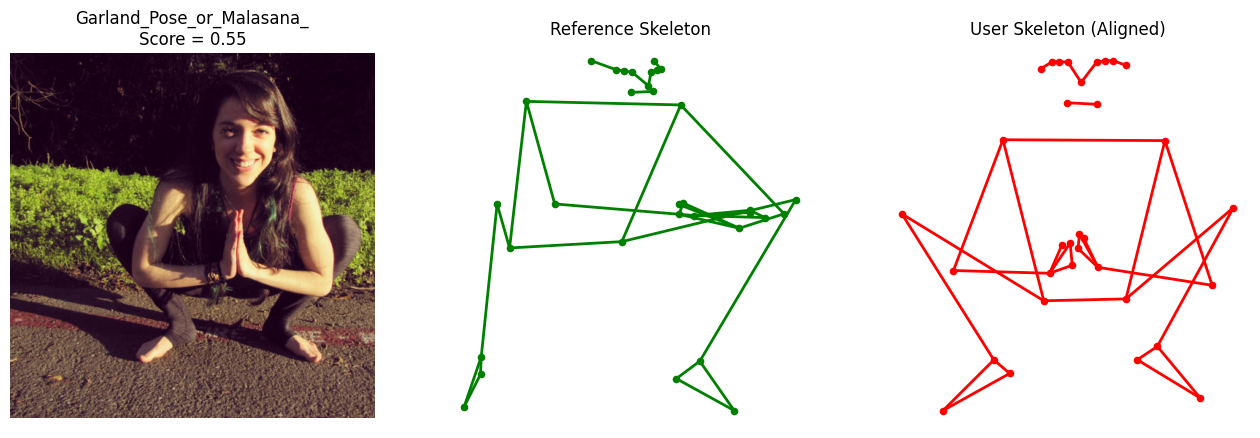


📌 Image: 574.jpg
Pose Class: Garland_Pose_or_Malasana_
Final Score: 0.550
Angle Score: 0.898
Skeleton Score: 0.028
Mean Skeleton Dist: 0.5845

Angle deviations (deg):
Left Elbow      User:  66.4  Ref:  93.0  Δ:  26.6
Right Elbow     User:  71.0  Ref:  94.2  Δ:  23.2
Left Shoulder   User:  51.2  Ref:  44.6  Δ:   6.6
Right Shoulder  User:  48.4  Ref:  49.4  Δ:   1.1
Left Hip        User:  31.1  Ref:  43.3  Δ:  12.1
Right Hip       User:  35.0  Ref:  48.0  Δ:  13.1
Left Knee       User:  19.8  Ref:  49.7  Δ:  30.0
Right Knee      User:  25.1  Ref:  49.4  Δ:  24.3
Torso Tilt      User:   3.0  Ref:  29.9  Δ:  26.9

Top skeleton joint deviations:
Joint 32: 1.0915
Joint 31: 1.0673
Joint 14: 0.9547
Joint 30: 0.9504
Joint 29: 0.8814
--------------------------------------------------



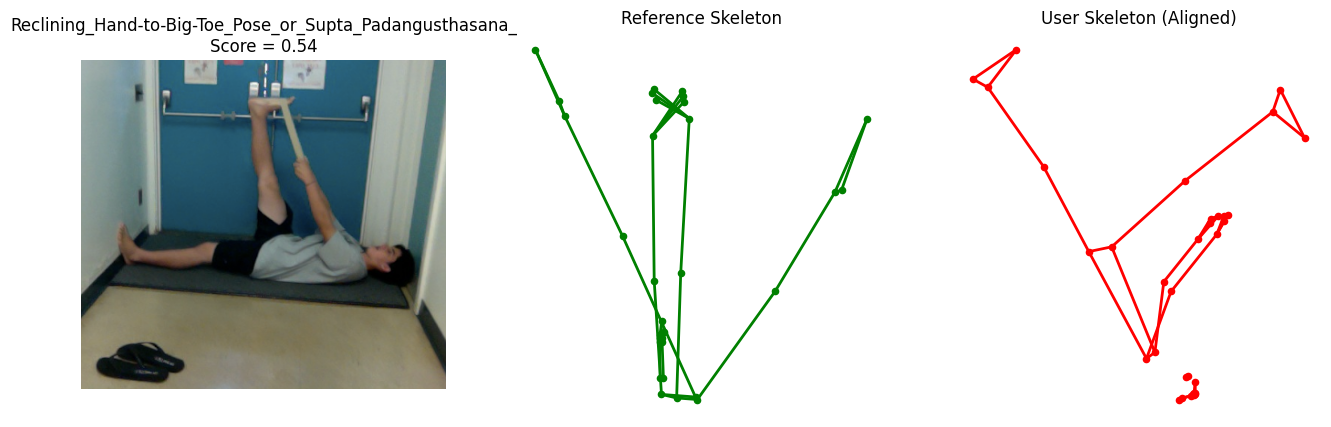


📌 Image: 458.jpg
Pose Class: Reclining_Hand-to-Big-Toe_Pose_or_Supta_Padangusthasana_
Final Score: 0.544
Angle Score: 0.907
Skeleton Score: 0.000
Mean Skeleton Dist: 1.9339

Angle deviations (deg):
Left Elbow      User: 132.1  Ref: 142.9  Δ:  10.8
Right Elbow     User: 105.6  Ref: 145.9  Δ:  40.2
Left Shoulder   User:  58.8  Ref:  55.0  Δ:   3.8
Right Shoulder  User:  49.0  Ref:  56.8  Δ:   7.8
Left Hip        User: 123.7  Ref: 111.1  Δ:  12.5
Right Hip       User: 103.2  Ref: 125.9  Δ:  22.7
Left Knee       User: 151.6  Ref: 168.3  Δ:  16.7
Right Knee      User: 168.7  Ref: 160.5  Δ:   8.3
Torso Tilt      User:  97.4  Ref:  92.6  Δ:   4.8

Top skeleton joint deviations:
Joint 32: 4.0194
Joint 31: 3.7493
Joint 30: 3.3614
Joint 28: 3.1238
Joint 29: 2.9384
--------------------------------------------------



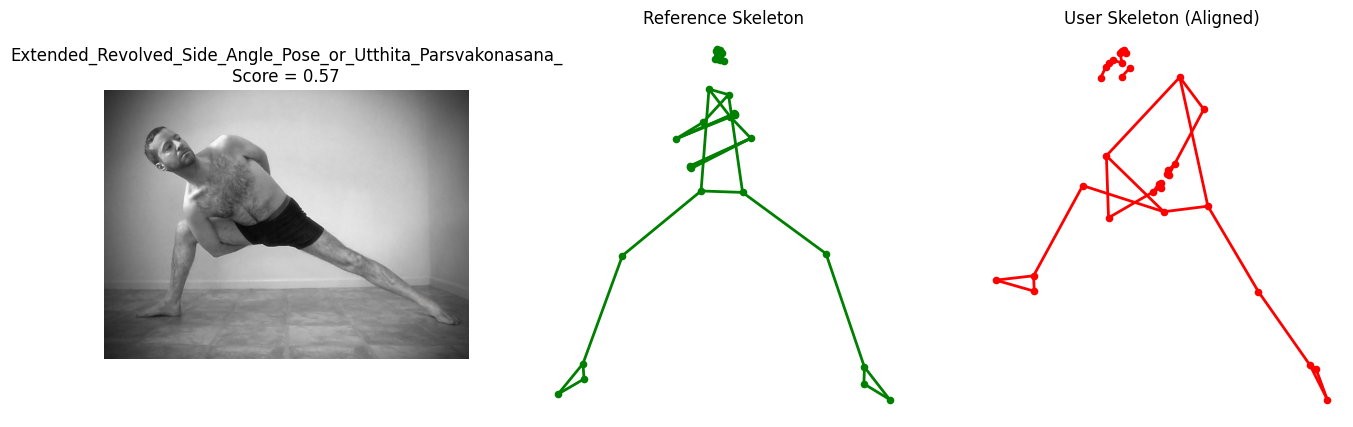


📌 Image: 1_506.jpg
Pose Class: Extended_Revolved_Side_Angle_Pose_or_Utthita_Parsvakonasana_
Final Score: 0.570
Angle Score: 0.834
Skeleton Score: 0.174
Mean Skeleton Dist: 0.5024

Angle deviations (deg):
Left Elbow      User: 157.2  Ref: 156.3  Δ:   0.9
Right Elbow     User: 122.9  Ref: 155.0  Δ:  32.1
Left Shoulder   User:  50.4  Ref:  97.1  Δ:  46.7
Right Shoulder  User:  25.5  Ref:  96.7  Δ:  71.2
Left Hip        User: 136.4  Ref:  98.1  Δ:  38.3
Right Hip       User:  52.4  Ref: 107.8  Δ:  55.4
Left Knee       User: 133.7  Ref: 137.0  Δ:   3.2
Right Knee      User:  96.4  Ref: 142.2  Δ:  45.8
Torso Tilt      User:  42.8  Ref:  56.2  Δ:  13.4

Top skeleton joint deviations:
Joint 14: 1.1090
Joint 32: 0.9980
Joint 28: 0.8085
Joint 30: 0.7998
Joint 26: 0.7312
--------------------------------------------------



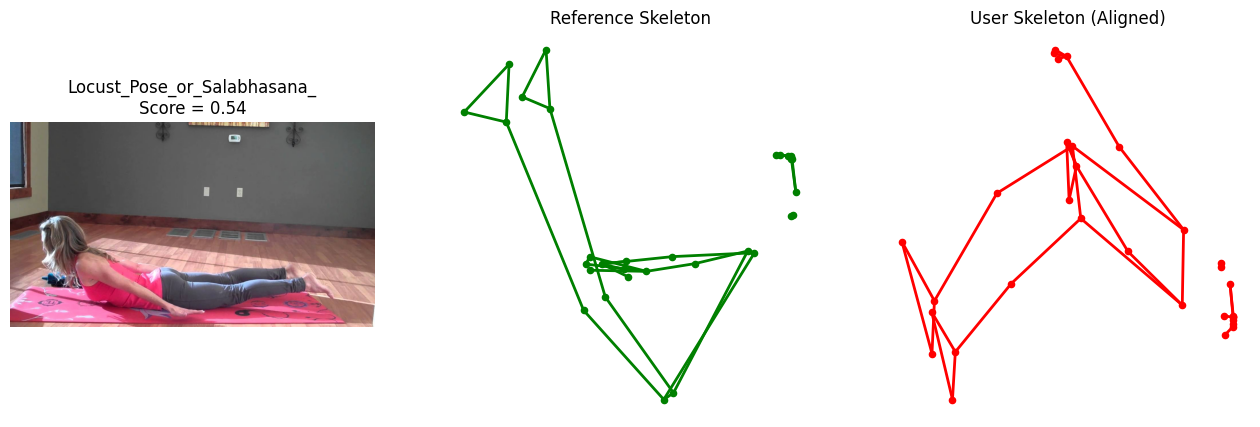


📌 Image: 303.jpg
Pose Class: Locust_Pose_or_Salabhasana_
Final Score: 0.545
Angle Score: 0.908
Skeleton Score: 0.000
Mean Skeleton Dist: 0.8680

Angle deviations (deg):
Left Elbow      User: 161.9  Ref: 164.6  Δ:   2.6
Right Elbow     User: 148.9  Ref: 162.6  Δ:  13.7
Left Shoulder   User:  36.0  Ref:  30.2  Δ:   5.8
Right Shoulder  User:  21.0  Ref:  33.2  Δ:  12.1
Left Hip        User: 154.5  Ref: 150.2  Δ:   4.3
Right Hip       User: 134.4  Ref: 150.1  Δ:  15.7
Left Knee       User: 157.9  Ref: 166.1  Δ:   8.3
Right Knee      User: 160.5  Ref: 163.2  Δ:   2.7
Torso Tilt      User:  59.6  Ref:  78.4  Δ:  18.8

Top skeleton joint deviations:
Joint 23: 2.2406
Joint 24: 2.0041
Joint 25: 1.4429
Joint 29: 1.3473
Joint 30: 1.2947
--------------------------------------------------



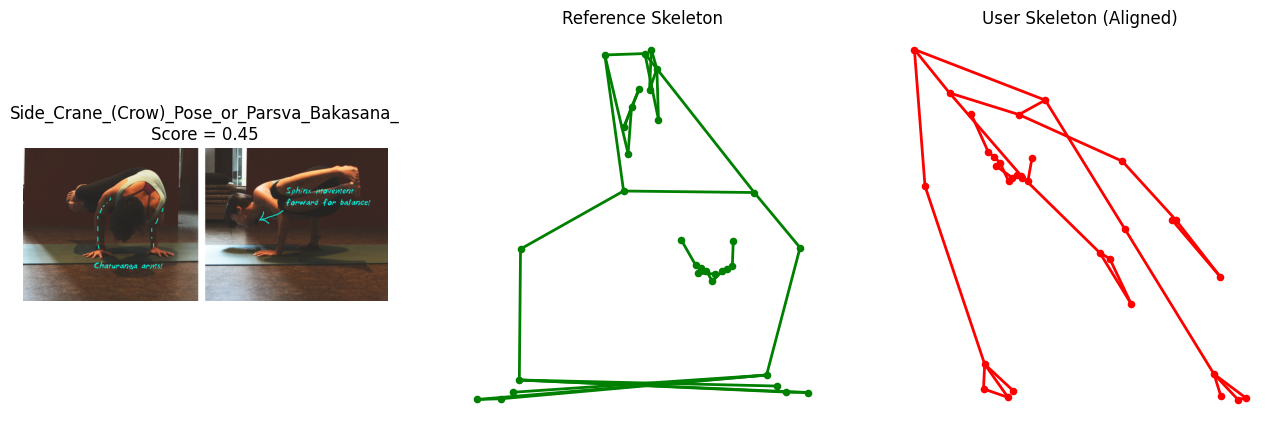


📌 Image: 2_305.jpg
Pose Class: Side_Crane_(Crow)_Pose_or_Parsva_Bakasana_
Final Score: 0.447
Angle Score: 0.745
Skeleton Score: 0.000
Mean Skeleton Dist: 1.8047

Angle deviations (deg):
Left Elbow      User: 164.7  Ref: 122.6  Δ:  42.1
Right Elbow     User: 137.4  Ref: 119.1  Δ:  18.4
Left Shoulder   User:  64.9  Ref:  66.6  Δ:   1.6
Right Shoulder  User:  36.9  Ref:  66.8  Δ:  29.9
Left Hip        User: 127.5  Ref:  90.7  Δ:  36.7
Right Hip       User: 161.6  Ref:  79.9  Δ:  81.7
Left Knee       User: 157.3  Ref: 108.0  Δ:  49.3
Right Knee      User: 177.0  Ref:  99.2  Δ:  77.8
Torso Tilt      User:  42.6  Ref: 120.0  Δ:  77.3

Top skeleton joint deviations:
Joint 18: 3.0150
Joint 29: 2.9655
Joint 20: 2.9562
Joint 22: 2.8570
Joint 19: 2.8097
--------------------------------------------------



In [29]:
import random
import cv2
import numpy as np
import pandas as pd
import mediapipe as mp
import matplotlib.pyplot as plt
from pathlib import Path

# ========= PATHS =========
DATA_DIR = Path("../data/split/test")  # your test folder
TEMPLATE_FILE = Path("../data/processed/class_skeleton_templates.npz")
ANGLE_MEAN_CSV = Path("../data/processed/class_angle_templates.csv")
ANGLE_STD_CSV = Path("../data/processed/class_angle_templates_std.csv")

# ========= LOAD TEMPLATES =========
tmp = np.load(TEMPLATE_FILE, allow_pickle=True)
TEMPLATES = {k.replace("_mean",""): tmp[k] for k in tmp.files if k.endswith("_mean")}
STD = {k.replace("_std",""): tmp[k] for k in tmp.files if k.endswith("_std")}

df_angle_mean = pd.read_csv(ANGLE_MEAN_CSV, index_col=0)
df_angle_std = pd.read_csv(ANGLE_STD_CSV, index_col=0)

# ========= MEDIA PIPE =========
mp_pose = mp.solutions.pose.Pose(static_image_mode=True)
mp_drawing = mp.solutions.drawing_utils
POSE_CONN = mp.solutions.pose.POSE_CONNECTIONS

# ========= KEYPOINT MAP =========
MP_IDX = {
    'nose':0,'left_shoulder':11,'right_shoulder':12,'left_elbow':13,'right_elbow':14,
    'left_wrist':15,'right_wrist':16,'left_hip':23,'right_hip':24,
    'left_knee':25,'right_knee':26,'left_ankle':27,'right_ankle':28
}

# ========= ANGLE FUNCTION =========
def _angle(a,b,c):
    a,b,c = np.array(a),np.array(b),np.array(c)
    ba = a-b; bc = c-b
    cosang = np.dot(ba,bc)/(np.linalg.norm(ba)*np.linalg.norm(bc)+1e-6)
    return np.degrees(np.arccos(np.clip(cosang,-1,1)))

def compute_angles(kps):
    idx = MP_IDX
    v = []
    v.append(_angle(kps[idx['left_shoulder']],kps[idx['left_elbow']],kps[idx['left_wrist']]))
    v.append(_angle(kps[idx['right_shoulder']],kps[idx['right_elbow']],kps[idx['right_wrist']]))
    v.append(_angle(kps[idx['left_elbow']],kps[idx['left_shoulder']],kps[idx['left_hip']]))
    v.append(_angle(kps[idx['right_elbow']],kps[idx['right_shoulder']],kps[idx['right_hip']]))
    v.append(_angle(kps[idx['left_shoulder']],kps[idx['left_hip']],kps[idx['left_knee']]))
    v.append(_angle(kps[idx['right_shoulder']],kps[idx['right_hip']],kps[idx['right_knee']]))
    v.append(_angle(kps[idx['left_hip']],kps[idx['left_knee']],kps[idx['left_ankle']]))
    v.append(_angle(kps[idx['right_hip']],kps[idx['right_knee']],kps[idx['right_ankle']]))
    mid_hip = (kps[idx['left_hip']] + kps[idx['right_hip']]) / 2
    mid_sh = (kps[idx['left_shoulder']] + kps[idx['right_shoulder']]) / 2

# Use only x,y for torso tilt
    v2 = (mid_sh[:2] - mid_hip[:2])
    ref = np.array([0, -1])  # vertical up in image coordinates

    ang = np.degrees(np.arccos(
        np.clip(np.dot(v2, ref) / (np.linalg.norm(v2) + 1e-6), -1, 1)
    ))
    v.append(ang)

    return np.array(v)

# ========= NORMALIZE & ALIGN =========
def normalize_xy(lm):
    L,R = MP_IDX['left_hip'], MP_IDX['right_hip']
    ls,rs = MP_IDX['left_shoulder'], MP_IDX['right_shoulder']
    mid_hip = (lm[L]+lm[R])/2
    sh_dist = np.linalg.norm(lm[ls]-lm[rs]); sh_dist = max(sh_dist,1e-4)
    return (lm-mid_hip)/sh_dist

def facing(lm):
    val = (lm[MP_IDX['right_shoulder']][0] - lm[MP_IDX['left_shoulder']][0])
    return 1 if val>0 else -1

def procrustes(A,B):
    muA=A.mean(0); muB=B.mean(0)
    A2=A-muA; B2=B-muB
    U,s,VT=np.linalg.svd(A2.T@B2)
    R=U@VT
    if np.linalg.det(R)<0: U[:,-1]*=-1; R=U@VT
    A2=A2@R
    return A2

def skeleton_score(user, tpl):
    d = np.mean(np.linalg.norm(user-tpl,axis=1))
    return max(0,1-d*3) # scale

# def analyze_and_print_details(cls, lm, angles, templates):
#     """Print detailed pose analysis scores and deviations."""

#     res = evaluate_pose(lm[:,:2], angles, cls, templates)

#     ang = res["angles"]
#     sk  = res["skeleton"]

#     print("\n================ POSE ANALYSIS =================")
#     print(f"Pose Class: {cls}")
#     print("-----------------------------------------------")

#     print(f"Angle Score        : {ang['angle_score']:.3f}")
#     print(f"Skeleton Score     : {sk['skeleton_score']:.3f}")
#     print(f"Fused Score        : {res['fused_score']:.3f}")
#     print(f"Mean Skeleton Dist : {sk['mean_dist']:.4f}")
#     print("-----------------------------------------------")

#     # Print angle deviations
#     print("\nAngle Deviations (deg):")
#     print("Joint              | User | Ref | ΔError | Normalized")
#     for i, name in enumerate(ANGLE_NAMES):
#         ua = angles[i]
#         ra = templates['angle_mean'].loc[cls].values[i]
#         err = ang['angle_errors'][i]
#         serr = ang['angle_normed'][i]
#         print(f"{name:<17s} | {ua:>5.1f} | {ra:>5.1f} | {err:>6.1f} | {serr:>9.3f}")

#     # Print top joints to correct
#     idx_sorted = np.argsort(-sk['per_joint_dist'])
#     bad_joints = idx_sorted[:5]  # top 5 errors
#     print("\nMost Deviated Joints (Skeleton):")
#     for j in bad_joints:
#         print(f"Joint {j:>2d} -> deviation {sk['per_joint_dist'][j]:.4f}")

#     print("================================================\n")

# ---- Prepare template tuple for evaluate_pose() ----
sk_mean  = TEMPLATES           # dict: class -> (33,2) mean skeleton
sk_std   = STD                 # dict: class -> (33,2) std skeleton
angle_mean_df = df_angle_mean  # DataFrame
angle_std_df  = df_angle_std   # DataFrame

EVAL_TEMPLATES = (sk_mean, sk_std, angle_mean_df, angle_std_df)

# ---- Pick random test samples ----
classes = list(TEMPLATES.keys())
test_paths = []

for cls in classes:
    folder = DATA_DIR / cls
    if folder.exists():
        imgs = list(folder.glob("*.jpg")) + list(folder.glob("*.png"))
        if imgs:
            test_paths.append(random.choice(imgs))

test_paths = random.sample(test_paths, 5)

# ---- Evaluate & visualize ----
for img_path in test_paths:
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"[SKIP] Could not load: {img_path}")
        continue

    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    r = mp_pose.process(rgb)

    if not r.pose_landmarks:
        print(f"[NO POSE] {img_path}")
        continue

    lm = np.array([[p.x, p.y, p.z] for p in r.pose_landmarks.landmark], dtype=np.float32)
    cls = img_path.parent.name

    angles = compute_angles(lm)
    if angles is None:
        print(f"[ANGLE FAIL] {img_path}")
        continue

    # Evaluate pose
    res = evaluate_pose(lm[:, :2], angles, cls, EVAL_TEMPLATES)

    # Get skeletons
    ref = TEMPLATES[cls]               # (33,2)
    user = normalize_xy(lm[:, :2])     # (33,2)

    # Mirror correction
    if facing(user) != facing(ref):
        user[:, 0] *= -1

    # Procrustes alignment
    user_aligned = procrustes(user, ref)

    # --- Plot results ---
    fig, ax = plt.subplots(1, 3, figsize=(16, 5))
    ax[0].imshow(rgb)
    ax[0].set_title(f"{cls}\nScore = {res['fused_score']:.2f}")
    ax[0].axis("off")

    def draw_skel(ax, pts, color):
        for (i, j) in POSE_CONN:
            ax.plot([pts[i,0], pts[j,0]], [-pts[i,1], -pts[j,1]], color, lw=2)
        ax.scatter(pts[:,0], -pts[:,1], c=color, s=20)
        ax.axis("off")

    ax[1].set_title("Reference Skeleton")
    draw_skel(ax[1], ref, "green")

    ax[2].set_title("User Skeleton (Aligned)")
    draw_skel(ax[2], user_aligned, "red")

    plt.show()

    # --- Print Key Metrics ---
    print(f"\n📌 Image: {img_path.name}")
    print(f"Pose Class: {cls}")
    print(f"Final Score: {res['fused_score']:.3f}")
    print(f"Angle Score: {res['angles']['angle_score']:.3f}")
    print(f"Skeleton Score: {res['skeleton']['skeleton_score']:.3f}")
    print(f"Mean Skeleton Dist: {res['skeleton']['mean_dist']:.4f}")

    print("\nAngle deviations (deg):")
    for name, ua, ra, ae in zip(
        ANGLE_NAMES, angles, angle_mean_df.loc[cls].values, res['angles']['angle_errors']
    ):
        print(f"{name:<15} User:{ua:6.1f}  Ref:{ra:6.1f}  Δ:{ae:6.1f}")

    print("\nTop skeleton joint deviations:")
    joint_idx = np.argsort(-res['skeleton']['per_joint_dist'])[:5]
    for j in joint_idx:
        print(f"Joint {j:2d}: {res['skeleton']['per_joint_dist'][j]:.4f}")

    print("--------------------------------------------------\n")

